In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [91]:
# URLs de datos de Airbnb
url_listings = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2025-06-12/visualisations/listings.csv"
url_listings_det = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2025-06-12/data/listings.csv.gz"

# Importar datasets
listings = pd.read_csv(url_listings)
listings_det = pd.read_csv(url_listings_det)

In [92]:
print(f"listings: {listings.shape}")

print(f"listings_det: {listings_det.shape}")

listings.head(3)

listings: (26004, 18)
listings_det: (26004, 79)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,29.0,4,33,2018-07-15,0.25,2,340,0,NaN
1,30320,Apartamentos Dana Sol,130907,Dana,Centro,Sol,40.41476,-3.70418,Entire home/apt,NaN,5,172,2022-09-26,0.94,3,337,0,NaN
2,30959,Beautiful loft in Madrid Center,132883,Angela,Centro,Embajadores,40.41259,-3.70105,Entire home/apt,NaN,3,8,2017-05-30,0.06,1,0,0,NaN


In [93]:
listings.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='str')

In [94]:
# Eliminar variables que no nos aportan valor.
# No vamos a eliminar la variable id ya que vincula ambos datasets
a_eliminar= ['host_id', 'host_name','number_of_reviews', 'last_review',
       'reviews_per_month','calculated_host_listings_count','number_of_reviews_ltm', 'license']

listings = listings.drop(columns= a_eliminar)
listings.head(5)

,id,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,availability_365
0,21853,Bright and airy room,Latina,Cármenes,40.40381,-3.74130,Private room,29.0,4,340
1,30320,Apartamentos Dana Sol,Centro,Sol,40.41476,-3.70418,Entire home/apt,NaN,5,337
2,30959,Beautiful loft in Madrid Center,Centro,Embajadores,40.41259,-3.70105,Entire home/apt,NaN,3,0
3,40916,Apartasol Apartamentos Dana,Centro,Universidad,40.42247,-3.70577,Entire home/apt,NaN,5,352
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Centro,Justicia,40.41884,-3.69655,Private room,64.0,1,314


In [95]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 26004 entries, 0 to 26003
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   26004 non-null  int64  
 1   name                 26004 non-null  str    
 2   neighbourhood_group  26004 non-null  str    
 3   neighbourhood        26004 non-null  str    
 4   latitude             26004 non-null  float64
 5   longitude            26004 non-null  float64
 6   room_type            26004 non-null  str    
 7   price                20080 non-null  float64
 8   minimum_nights       26004 non-null  int64  
 9   availability_365     26004 non-null  int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 2.0 MB


In [96]:
#analisis de nulos
listings.isnull().sum()

id                        0
name                      0
neighbourhood_group       0
neighbourhood             0
latitude                  0
longitude                 0
room_type                 0
price                  5924
minimum_nights            0
availability_365          0
dtype: int64

In [97]:
#Eliminar registros que contienen nulos debido a que no son muchos y no queremos imputar datos debido a la naturaleza del proyecto

listings = listings.dropna()
listings.isnull().sum()

id                     0
name                   0
neighbourhood_group    0
neighbourhood          0
latitude               0
longitude              0
room_type              0
price                  0
minimum_nights         0
availability_365       0
dtype: int64

In [98]:
#revisar si existen duplicados
listings.duplicated().sum()

np.int64(0)

In [99]:
# Analisis previo de variables categoricas(value counts de variables tipo string)
str_cols = listings.select_dtypes(include='object').columns

for col in str_cols:
    print(f"\n{'='*60}")
    print(f"Variable: {col}")
    print(f"{'='*60}")
    print(listings[col].value_counts())


Variable: name
name
Habitación en piso compartido                       172
Habitación con baño privado                          30
Habitación en Madrid                                 19
Fantastic residence ``FUNWAY´´ north zone Madrid     16
Habitación piso compartido                           15
                                                   ... 
Private Room Near Atocha                              1
Bahia - 3 bedrooms and balcony in Niño Jesús          1
apartamento en plaza mayor                            1
Hermoso piso en el centro                             1
Cozy suite - Bravo Murillo                            1
Name: count, Length: 18648, dtype: int64

Variable: neighbourhood_group
neighbourhood_group
Centro                   8372
Tetuán                   1420
Salamanca                1372
Chamberí                 1267
Arganzuela               1008
Retiro                    754
Chamartín                 711
Carabanchel               700
Ciudad Lineal             696
P

C:\Users\Jordi\AppData\Local\Temp\ipykernel_50748\2110066793.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = listings.select_dtypes(include='object').columns


In [100]:
#eliminar registros donde roomtype es "Hotel room" ya que no es el tipo de alojamiento que queremos analizar
listings = listings[listings['room_type'] != 'Hotel room']


In [101]:
#Analisis previo de variables numericas
listings.iloc[:, 7:10].describe().T

,count,mean,std,min,25%,50%,75%,max
price,20026.0,145.040497,485.948741,0.0,64.0,100.0,150.0,32000.0
minimum_nights,20026.0,8.167582,18.057040,1.0,1.0,2.0,4.0,365.0
availability_365,20026.0,202.919105,121.338330,0.0,87.0,220.0,320.0,365.0


In [102]:
#conclusion (price): tenemos que hacer una inspeccion mas detallada de "price" para determinar que valores extremos tenemos y si es necesario eliminarlos o no.
#conclusion (minimum_nights): la media nos saca un valor poco realista. En cambio, la mediana al 50% y 75% no dice que se suelen alquilar entre 2-4 noches.
#conclusion(availability_365): nada a destacar, valores maximos de 365 dias (alquileres anuales).

Registros con precio < 50: 3431 de 20026


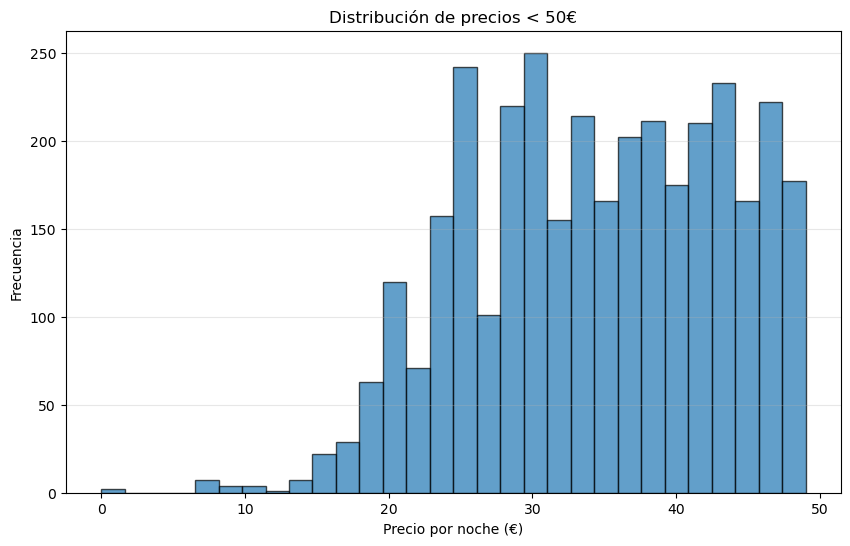

In [18]:
# Filtrar registros con precio < 50
listings_precio_bajo = listings[listings['price'] < 50]

print(f"Registros con precio < 50: {len(listings_precio_bajo)} de {len(listings)}")

# Generar histograma
plt.figure(figsize=(10, 6))
plt.hist(listings_precio_bajo['price'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Precio por noche (€)')
plt.ylabel('Frecuencia')
plt.title('Distribución de precios < 50€')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# 20 seria un buen punto de corte porque a partir de ese punto la frecuencia de precios es muy baja y se podrían considerar como valores atípicos.
# Sin embargo, esta decisión también dependerá del contexto del análisis y de los objetivos del proyecto.

Registros con precio > 1000: 94 de 20026


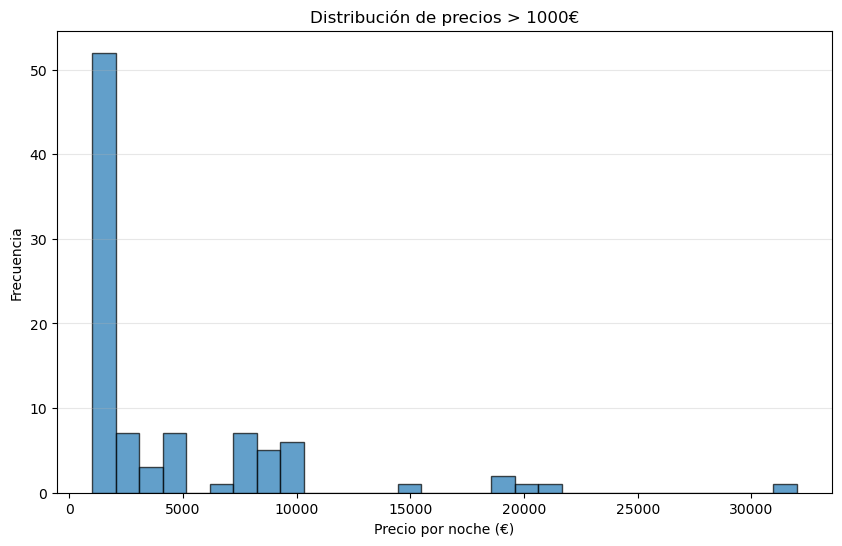

In [103]:
# Filtrar registros con precio > 300
listings_precio_alto = listings[listings['price'] > 1000]

print(f"Registros con precio > 1000: {len(listings_precio_alto)} de {len(listings)}")

# Generar histograma
plt.figure(figsize=(10, 6))
plt.hist(listings_precio_alto['price'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Precio por noche (€)')
plt.ylabel('Frecuencia')
plt.title('Distribución de precios > 1000€')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
#concl: para este caso, lo logico seria sentarse con el de negocio y hacer este ejercicio de forma intercativa para determinar los puntos de corte mas adecuados.
# En este caso, se han elegido 20€ y 1000€ como puntos de corte para eliminar los valores atípicos en la variable "price".

In [104]:
#qudarnos con registros entre 20 y 1000 euros noche
listings = listings[(listings['price'] >= 20) & (listings['price'] <= 1000)]

listings.iloc[:, 7:10].describe().T

,count,mean,std,min,25%,50%,75%,max
price,19793.0,125.337139,104.652455,20.0,65.0,101.0,150.0,1000.0
minimum_nights,19793.0,8.070429,17.891594,1.0,1.0,2.0,4.0,365.0
availability_365,19793.0,203.108574,121.352122,0.0,87.0,220.0,320.0,365.0


In [105]:
#calidad de datosa de listings_det
listings_det.info()

<class 'pandas.DataFrame'>
RangeIndex: 26004 entries, 0 to 26003
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            26004 non-null  int64  
 1   listing_url                                   26004 non-null  str    
 2   scrape_id                                     26004 non-null  int64  
 3   last_scraped                                  26004 non-null  str    
 4   source                                        26004 non-null  str    
 5   name                                          26004 non-null  str    
 6   description                                   25104 non-null  str    
 7   neighborhood_overview                         11158 non-null  str    
 8   picture_url                                   26002 non-null  str    
 9   host_id                                       26004 non-null  int64  
 1

In [106]:
listings_det.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250612050748,2025-06-26,city scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,...,4.82,4.21,4.67,NaN,f,2,0,2,0,0.25
1,30320,https://www.airbnb.com/rooms/30320,20250612050748,2025-06-27,previous scrape,Apartamentos Dana Sol,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409...,130907,...,4.78,4.90,4.69,NaN,f,3,3,0,0,0.94
2,30959,https://www.airbnb.com/rooms/30959,20250612050748,2025-06-27,previous scrape,Beautiful loft in Madrid Center,Beautiful Loft 60m2 size just in the historica...,NaN,https://a0.muscache.com/pictures/78173471/835e...,132883,...,4.63,4.88,4.25,NaN,f,1,1,0,0,0.06
3,40916,https://www.airbnb.com/rooms/40916,20250612050748,2025-06-26,previous scrape,Apartasol Apartamentos Dana,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,130907,...,4.79,4.88,4.55,NaN,t,3,3,0,0,0.27
4,62423,https://www.airbnb.com/rooms/62423,20250612050748,2025-06-25,city scrape,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,DISTRICT WITH VERY GOOD VIBES IN THE MIDDLE OF...,https://a0.muscache.com/pictures/miso/Hosting-...,303845,...,4.86,4.97,4.59,NaN,f,3,1,2,0,2.70


In [30]:
#variables a incluir en el dataset final
a_incluir = ['id',
             'description',
             'accommodates',
             'bathrooms',
             'bedrooms',
             'beds',
             'estimated_occupancy_l365d',
             'estimated_revenue_l365d',
             'review_scores_location']

listings_det = listings_det[a_incluir]
listings_det.info()

<class 'pandas.DataFrame'>
RangeIndex: 26004 entries, 0 to 26003
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         26004 non-null  int64  
 1   description                25104 non-null  str    
 2   accommodates               26004 non-null  int64  
 3   bathrooms                  20065 non-null  float64
 4   bedrooms                   23550 non-null  float64
 5   beds                       20069 non-null  float64
 6   estimated_occupancy_l365d  26004 non-null  int64  
 7   estimated_revenue_l365d    20080 non-null  float64
 8   review_scores_location     20759 non-null  float64
dtypes: float64(5), int64(3), str(1)
memory usage: 1.8 MB


In [31]:
#analisis de nulos
listings_det.isnull().sum()

id                              0
description                   900
accommodates                    0
bathrooms                    5939
bedrooms                     2454
beds                         5935
estimated_occupancy_l365d       0
estimated_revenue_l365d      5924
review_scores_location       5245
dtype: int64

In [33]:
#eliminamos estimated_revenue_l365d debido a que concocemos como generarla y podemos hacerlo a posterior (estimated ocupancy/year x price)
listings_det = listings_det.drop(columns='estimated_revenue_l365d')
listings_det.info()

<class 'pandas.DataFrame'>
RangeIndex: 26004 entries, 0 to 26003
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         26004 non-null  int64  
 1   description                25104 non-null  str    
 2   accommodates               26004 non-null  int64  
 3   bathrooms                  20065 non-null  float64
 4   bedrooms                   23550 non-null  float64
 5   beds                       20069 non-null  float64
 6   estimated_occupancy_l365d  26004 non-null  int64  
 7   review_scores_location     20759 non-null  float64
dtypes: float64(4), int64(3), str(1)
memory usage: 1.6 MB


In [36]:
#numero de registros con estimated_occupancy_l365d = 0
listings_det[listings_det['estimated_occupancy_l365d'] == 0].shape[0]

8911

In [ ]:
#Tenemos un problema, availability_365 no tiene nulos pero estimated_occupancy_l365d tiene muchos valores 0. Necesitamos saber la diferencia y entender cual
#es la variable que nos afecta en nuestro caso especifiuco de negocio. Por lo visto, estimated_occupancy_l365d nos indica la cantidac de dias que se espera que ese
# inmueble sea alquilado en el procimo año. Los valores 0 son debido a inmuebles nuevos que no tienen historial para generar este dato. En cambio availability_365 nos indica
# la cantidad de dias que ese inmueble estara disponible para alquilar en el proximo año. Esta variable seria desechable ya que no nos aporta valor para nuestro
# analisis.

# Conclusion: deberiamos hacer un proxy para reemplazar valores 0 de estimated_occupancy_l365d ya que es una variable muy relevante y necesitamos tenerlos. Debido a que este
# caso es pedagogico, solo haremos proxy para las variables bathrooms, bedrooms, beds para estimar los m2 del inmueble en base a esos parametros y eliminaremos los
# registros con estimated_occupancy_l365d = 0. 

In [37]:
#aliminar registros con estimated_occupancy_l365d = 0
listings_det = listings_det[listings_det['estimated_occupancy_l365d'] != 0]
listings_det.info()

<class 'pandas.DataFrame'>
Index: 17093 entries, 4 to 25977
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         17093 non-null  int64  
 1   description                16666 non-null  str    
 2   accommodates               17093 non-null  int64  
 3   bathrooms                  15501 non-null  float64
 4   bedrooms                   16589 non-null  float64
 5   beds                       15501 non-null  float64
 6   estimated_occupancy_l365d  17093 non-null  int64  
 7   review_scores_location     17092 non-null  float64
dtypes: float64(4), int64(3), str(1)
memory usage: 1.2 MB


In [38]:
#volvemos a hacer analisis de nulos para ver como quedan el resto de nulos al eliminar estos registros
listings_det.isnull().sum()

id                              0
description                   427
accommodates                    0
bathrooms                    1592
bedrooms                      504
beds                         1592
estimated_occupancy_l365d       0
review_scores_location          1
dtype: int64

In [55]:
#Primero eliminaremos valores extremos (de forma arbitraria, se podria hacer con algun requerimiento concreto, etc.).
#Visualizamos valores de todas las variables numericas importantes y eliminamos extremos.

listings_det.beds.value_counts(ascending = False).sort_index()

beds
0.0     294
1.0    6804
2.0    4622
3.0    1990
4.0    1001
5.0     319
6.0     102
Name: count, dtype: int64

In [ ]:
#eliminar registros con espacio para mas de 8 personas
listings_det = listings_det[listings_det.accommodates <= 8]

In [48]:
#eliminar registros con mas de 5 baños
listings_det = listings_det[listings_det.bathrooms <= 5]

In [51]:
#eliminar registros con espacio para mas de 5 habitaciones
listings_det = listings_det[listings_det.bedrooms <= 5]

In [54]:
#eliminar registros con espacio para mas de 6 camas
listings_det = listings_det[listings_det.beds <= 6]

In [56]:
#volvemos a visualizar nulos para ver como quedan despues de eliminar estos registros
listings_det.isnull().sum()

id                             0
description                  375
accommodates                   0
bathrooms                      0
bedrooms                       0
beds                           0
estimated_occupancy_l365d      0
review_scores_location         1
dtype: int64

In [59]:
#No haria falta hacer proxy ya que hemos despejado los nulos, pero lo haremos igualmente para practicar como deberiamos hacerlo:
#crosstab entre accommodates y bedrooms para ver la relacion entre ambas variables y poder hacer un proxy de bedrooms en base a accommodates
pd.crosstab(listings_det['accommodates'], listings_det['bedrooms'])

bedrooms,0.0,1.0,2.0,3.0,4.0,5.0
accommodates,,,,,,
1,49,1517,43,10,12,12
2,640,4584,77,5,12,2
3,154,1074,326,10,1,0
4,285,2267,1479,72,2,0
5,12,77,414,177,6,3
6,8,90,777,447,21,1
7,2,7,22,77,30,1
8,2,5,49,181,88,2


In [ ]:
#La forma de hacer este proxy es usar una variable como proxy (en este caso accommodates) para estimar los valores de otra variable (bedrooms) en base a la relacion que existe entre ambas variables.
# Usamos el valor mayoritario de accomodates para definir bedrooms. Por ejemplo:
# Entre 1 y 4 accomodates -> 1 bedroom
# 5 accomodates -> 2 bedrooms
# 6 y 8 accomodates -> 3 bedrooms

In [61]:
#Seguimos con la calidad de datos de listings_det -> comprobar duplicados
listings_det.duplicated().sum()

np.int64(0)

In [ ]:
# Ahora vamos a incorporar datos externos debido a que necesitamos variables que por ahora desconocemos como el precio m2/distrito y
# los m2 segun caracteristicas de inmueble (haremos un proxy).

In [67]:
# ========== PROCESAMIENTO DE DATOS DE PRECIO M2 ==========
# Cargar el archivo CSV
ruta_preciom2 = "../datos/brutos/preciom2_madrid_2025.csv"
df_idealista = pd.read_csv(ruta_preciom2)

In [68]:
df_idealista

,table__cell 2,icon-elbow
0,5.960 €/m2,NaN
1,6.334 €/m2,Arganzuela
2,4.901 €/m2,Barajas
3,3.718 €/m2,Carabanchel
4,7.566 €/m2,Centro
5,8.187 €/m2,Chamartín
6,8.992 €/m2,Chamberí
7,5.096 €/m2,Ciudad Lineal
8,5.423 €/m2,Fuencarral
9,5.411 €/m2,Hortaleza


In [70]:

# 1. Renombrar columnas
df_idealista.columns = ['precio', 'neighbourhood_group']
df_idealista.head(3)

,precio,neighbourhood_group
0,5.960 €/m2,NaN
1,6.334 €/m2,Arganzuela
2,4.901 €/m2,Barajas


In [71]:
# 2. Eliminar primer registro
df_idealista = df_idealista.iloc[1:].reset_index(drop=True)
df_idealista.head(3)

,precio,neighbourhood_group
0,6.334 €/m2,Arganzuela
1,4.901 €/m2,Barajas
2,3.718 €/m2,Carabanchel


In [73]:
# 3. Eliminar '€/m2' de la columna precio
df_idealista['precio'] = df_idealista['precio'].str.replace('€/m2', '').str.strip()

# 4. Eliminar separador de miles (.) y convertir a numerico
df_idealista['precio'] = df_idealista['precio'].str.replace('.', '').astype(float)

df_idealista.head(3)

,precio,neighbourhood_group
0,6334.0,Arganzuela
1,4901.0,Barajas
2,3718.0,Carabanchel


In [75]:
print("DESPUÉS del procesamiento:")
print(df_idealista.head(10))
print(f"\nTipos de datos:")
print(df_idealista.dtypes)
print(f"\nRegistros finales: {len(df_idealista)}")

DESPUÉS del procesamiento:
   precio neighbourhood_group
0  6334.0          Arganzuela
1  4901.0             Barajas
2  3718.0         Carabanchel
3  7566.0              Centro
4  8187.0           Chamartín
5  8992.0            Chamberí
6  5096.0       Ciudad Lineal
7  5423.0          Fuencarral
8  5411.0           Hortaleza
9  3916.0              Latina

Tipos de datos:
precio                 float64
neighbourhood_group        str
dtype: object

Registros finales: 21


In [117]:
distritos_i = df_idealista.neighbourhood_group.unique()
distritos_l = listings.neighbourhood_group.unique()

In [119]:
distritos_i

<StringArray>
[         'Arganzuela',             'Barajas',         'Carabanchel',
              'Centro',           'Chamartin',            'Chamberi',
       'Ciudad Lineal', 'Fuencarral-El Pardo',           'Hortaleza',
              'Latina',     'Moncloa-Aravaca',           'Moratalaz',
  'Puente de Vallecas',              'Retiro',           'Salamanca',
 'San Blas-Canillejas',              'Tetuan',               'Usera',
           'Vicalvaro',   'Villa de Vallecas',          'Villaverde']
Length: 21, dtype: str

In [120]:
distritos_l

<StringArray>
[               'Latina',                'Centro',              'Chamberí',
            'Villaverde',             'Hortaleza',            'Arganzuela',
                'Tetuán',                'Retiro',             'Salamanca',
 'San Blas - Canillejas',         'Ciudad Lineal',             'Chamartín',
                 'Usera',           'Carabanchel',               'Barajas',
 'Fuencarral - El Pardo',    'Puente de Vallecas',     'Moncloa - Aravaca',
             'Moratalaz',             'Vicálvaro',     'Villa de Vallecas']
Length: 21, dtype: str

In [121]:
#Cambio de valores de la variable neighbourhood_group de df_idealista para que coincida con listinmgs
reemplazos = {
    'Chamberi': 'Chamberí',
    'Chamartin': 'Chamartín',
    'Tetuan': 'Tetuán',
    'San Blas-Canillejas': 'San Blas - Canillejas',
    'Fuencarral-El Pardo': 'Fuencarral - El Pardo',
    'Moncloa-Aravaca': 'Moncloa - Aravaca',
    'Vicalvaro': 'Vicálvaro'
}

df_idealista['neighbourhood_group'] = df_idealista['neighbourhood_group'].replace(reemplazos)
df_idealista.neighbourhood_group.unique()

<StringArray>
[           'Arganzuela',               'Barajas',           'Carabanchel',
                'Centro',             'Chamartín',              'Chamberí',
         'Ciudad Lineal', 'Fuencarral - El Pardo',             'Hortaleza',
                'Latina',     'Moncloa - Aravaca',             'Moratalaz',
    'Puente de Vallecas',                'Retiro',             'Salamanca',
 'San Blas - Canillejas',                'Tetuán',                 'Usera',
             'Vicálvaro',     'Villa de Vallecas',            'Villaverde']
Length: 21, dtype: str

In [ ]:
#Crear base de datos para almacenar las tablas que vamos a usar en el proyecto

In [ ]:
# Crear base de datos SQLite y almacenar las tablas
import sqlite3
from pathlib import Path

# Definir ruta de la base de datos
db_path = Path("../datos/intermedios/airbnb_madrid.db")
db_path.parent.mkdir(parents=True, exist_ok=True)  # Crear carpeta si no existe

# Crear conexión y guardar los dataframes
with sqlite3.connect(db_path) as conn:
    listings.to_sql("listings", conn, if_exists="replace", index=False)
    listings_det.to_sql("listings_det", conn, if_exists="replace", index=False)
    df_idealista.to_sql("df_idealista", conn, if_exists="replace", index=False)

print(f"Tablas almacenadas en {db_path}")